# Sensitivity analysis — EWM half-life × min-dwell N (Phase 3)

**Goal:** Demonstrate that walk-forward smoothing parameters are not overfit to the main backtest window.

**Method:**
- Strategy: `bond_floor_tactical` (hard labels, K=5)
- Evaluation window: **1975–1990 only** (pre-1990 selection subsample)
- Grid: EWM half-life `h` × min-dwell `N`
- Metrics: Sharpe ratio (Figure A) and win rate / hit ratio (Figure B)

The 1990+ period is **never used** for parameter selection; it remains the
hold-out evaluation window reported in the main results.

---

**Win-rate formula** (used throughout the performance summary):

$$
\text{Win Rate} = \frac{1}{T}\sum_{t=1}^{T} \mathbf{1}\{r_t^{\text{net}} > 0\}
$$

where $r_t^{\text{net}}$ is the strategy's **net** monthly return after transaction
costs at month $t$, and $T$ is the number of months in the evaluation window.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def _find_pmr_root() -> Path:
    start = Path.cwd().resolve()
    for parent in [start, *start.parents]:
        if (parent / "scripts" / "paths.py").is_file():
            return parent
    raise FileNotFoundError("Run from inside pmr_paper/")


PROJECT_ROOT = _find_pmr_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.backtest.loaders import load_backtest_panel
from scripts.backtest.sensitivity import (
    half_life_to_span,
    plot_sensitivity_heatmaps,
    production_half_life,
    run_sensitivity_grid,
)
from scripts.paths import load_features

features = load_features()
returns_panel = load_backtest_panel(test_start="1975-01-31")

print(f"Features: {features.shape}  ({features.index.min().date()} → {features.index.max().date()})")
print(f"Returns panel: {returns_panel.shape}  ({returns_panel.index.min().date()} → {returns_panel.index.max().date()})")

Features: (663, 17)  (1971-03-31 → 2026-05-31)
Returns panel: (617, 3)  (1975-01-31 → 2026-05-31)


## Grid parameters

| Parameter | Values | Note |
|-----------|--------|------|
| EWM half-life `h` | 1, 2, 3, 4, 6, 9, 12 months | x-axis |
| Min-dwell `N` | 1, 2, 3, 4 months | y-axis |
| K | 5 | smoothing most impactful for K=5 |
| Strategy | `bond_floor_tactical` hard | top performer; equity+treasury only |
| Evaluation | 1975–1990 | pre-hold-out selection window |

In [2]:
# ── Grid configuration ──────────────────────────────────────────────────────
K = 5
STRATEGY_KEY = "bond_floor_tactical"

HALF_LIVES = [1, 2, 3, 4, 6, 9, 12]   # EWM half-life in months (x-axis)
DWELL_NS   = [1, 2, 3, 4]             # calm_dwell_months N (y-axis)

WF_TEST_START = "1975-01-31"           # walk-forward burn-in start
EVAL_START    = "1975-01-31"           # evaluation window start
EVAL_END      = "1990-12-31"           # evaluation window end (keep 1990+ clean)

# Production defaults (for heatmap annotation)
CHOSEN_H = round(production_half_life(K), 1)
CHOSEN_N = 2  # calm_dwell_months default in run_walk_forward

print(f"Production K={K}: half-life = {CHOSEN_H:.1f} months  |  dwell N = {CHOSEN_N}")
print(f"Grid size: {len(HALF_LIVES)} × {len(DWELL_NS)} = {len(HALF_LIVES)*len(DWELL_NS)} cells")

for h in HALF_LIVES:
    print(f"  h={h:2.0f}  →  span={half_life_to_span(h):.1f}")

Production K=5: half-life = 3.1 months  |  dwell N = 2
Grid size: 7 × 4 = 28 cells
  h= 1  →  span=3.0
  h= 2  →  span=5.8
  h= 3  →  span=8.7
  h= 4  →  span=11.6
  h= 6  →  span=17.3
  h= 9  →  span=26.0
  h=12  →  span=34.6


## Run sensitivity grid

Each of the 28 cells runs a full expanding walk-forward GMM on 1975–1990
with the given `(half-life, N)`, backtests `bond_floor_tactical` (hard), and
records Sharpe and win rate. Runtime: ~2–4 minutes.

In [3]:
print(f"Running {len(HALF_LIVES)*len(DWELL_NS)}-cell sensitivity grid on {WF_TEST_START} → {EVAL_END}...")

sharpe_grid, winrate_grid = run_sensitivity_grid(
    features=features,
    returns_panel=returns_panel,
    k=K,
    strategy_key=STRATEGY_KEY,
    half_lives=HALF_LIVES,
    dwell_ns=DWELL_NS,
    wf_test_start=WF_TEST_START,
    eval_start=EVAL_START,
    eval_end=EVAL_END,
    show_progress=False,
)

print("\n=== Sharpe ratio grid ===")
display(sharpe_grid.round(2))

print("\n=== Win rate grid ===")
display(winrate_grid.round(2))

Running 28-cell sensitivity grid on 1975-01-31 → 1990-12-31...
  [ 1/28]  half_life=  1.0  dwell_N=1
  SANITY CHECK (K=5)
  Oil Crisis / Stagflation        SKIPPED
  [FAIL] Volcker era                     want      Inflation >= 40%  |  got 23%  (Crisis:10, Inflation:11, Steady State:10, Walking on Ice:7, Bull Market:9)
  [PASS] Black Monday                    want         Crisis >= 25%  |  got 67%  (Crisis:2, Inflation:1)
  [PASS] GFC                             want         Crisis >= 30%  |  got 50%  (Crisis:10, Inflation:3, Steady State:2, Walking on Ice:3, Bull Market:2)
  [PASS] COVID crash                     want         Crisis >= 33%  |  got 100%  (Crisis:2)
  [FAIL] Dot-com / late 90s              want    Bull Market >= 30%  |  got 25%  (Crisis:3, Inflation:7, Steady State:28, Walking on Ice:6, Bull Market:15)
  [FAIL] Post-GFC expansion              want   Steady State >= 35%  |  got 21%  (Crisis:5, Inflation:18, Steady State:20, Walking on Ice:5, Bull Market:47)
  Result: SOM

half_life,1.0,2.0,3.0,4.0,6.0,9.0,12.0
dwell_N,,,,,,,
1,0.90,0.90,0.89,0.89,0.87,0.93,0.94
2,0.94,0.94,0.92,0.92,0.98,0.94,0.96
3,0.98,0.97,1.01,1.01,1.02,1.02,1.02
4,1.02,1.01,1.01,1.01,1.02,1.02,1.02



=== Win rate grid ===


half_life,1.0,2.0,3.0,4.0,6.0,9.0,12.0
dwell_N,,,,,,,
1,0.65,0.64,0.64,0.64,0.64,0.64,0.64
2,0.66,0.65,0.65,0.65,0.65,0.66,0.67
3,0.64,0.64,0.64,0.64,0.66,0.66,0.67
4,0.64,0.64,0.64,0.64,0.66,0.66,0.67


## Figure A — Sharpe ratio heatmap

Saved → /Users/antoinea/Desktop/Master_Thesis/outputs/figures/sensitivity_heatmaps.png


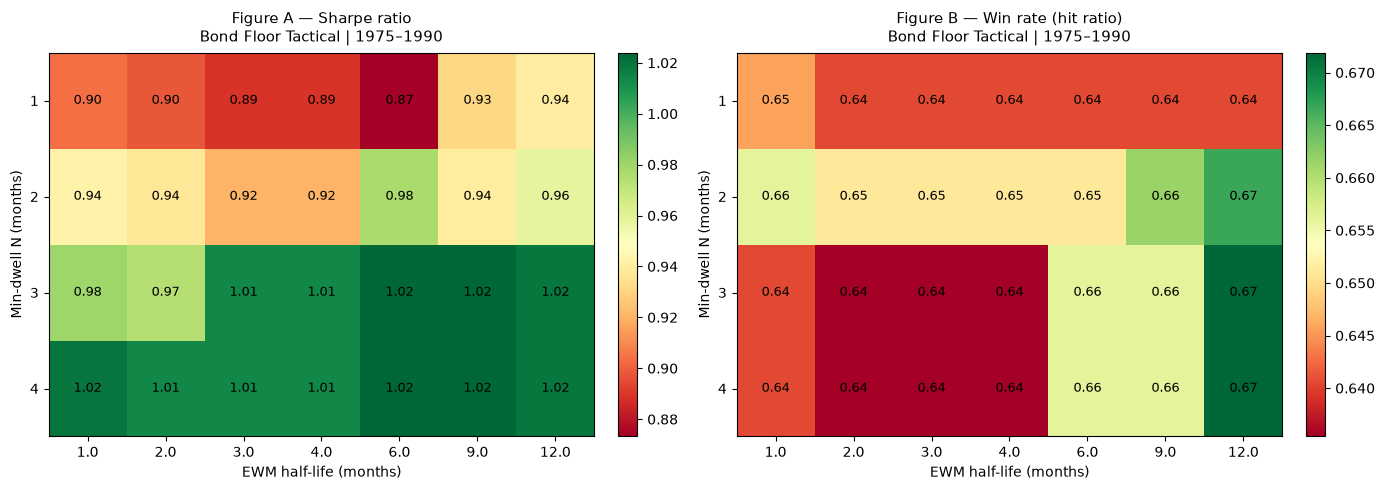

In [4]:
fig = plot_sensitivity_heatmaps(
    sharpe_grid,
    winrate_grid,
    chosen_h=CHOSEN_H,
    chosen_N=CHOSEN_N,
    strategy_key=STRATEGY_KEY,
    eval_start=EVAL_START[:4],
    eval_end=EVAL_END[:4],
)

fig_path = PROJECT_ROOT / "outputs" / "figures" / "sensitivity_heatmaps.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Saved → {fig_path}")
plt.show()